In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [8]:
# Load the data
prices = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\vietnam_stock_price_full.csv', index_col=0, parse_dates=True)
volumes = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\vietnam_stock_volume_full.csv', index_col=0, parse_dates=True)
FU = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\FU_VN30_full_fixed.csv', index_col=0, parse_dates=True)

In [11]:
prices.head(5)

,YEG,YBM,X20,WSS,WCS,VVS,VTZ,VTV,VTP,VTO,...,ACG,ACC,ACB,ABT,ABS,ABR,AAV,AAT,AAM,AAA
2014-07-09,NaN,NaN,NaN,5.1,33.04,NaN,NaN,3.35,NaN,2.92,...,NaN,5.32,2.37,21.56,NaN,NaN,NaN,NaN,7.13,6.08
2014-07-10,NaN,NaN,NaN,5.0,33.04,NaN,NaN,3.43,NaN,2.84,...,NaN,5.07,2.35,20.25,NaN,NaN,NaN,NaN,7.08,5.90
2014-07-11,NaN,NaN,NaN,4.9,29.78,NaN,NaN,3.41,NaN,2.84,...,NaN,5.26,2.35,20.64,NaN,NaN,NaN,NaN,7.38,5.81
2014-07-14,NaN,NaN,NaN,4.9,32.64,NaN,NaN,3.56,NaN,2.84,...,NaN,5.45,2.35,20.90,NaN,NaN,NaN,NaN,7.38,5.87
2014-07-15,NaN,NaN,NaN,5.0,32.64,NaN,NaN,3.48,NaN,2.88,...,NaN,5.26,2.37,21.08,NaN,NaN,NaN,NaN,7.38,5.90


In [12]:
volumes.head(5)

,YEG,YBM,X20,WSS,WCS,VVS,VTZ,VTV,VTP,VTO,...,ACG,ACC,ACB,ABT,ABS,ABR,AAV,AAT,AAM,AAA
2014-07-09,NaN,NaN,NaN,481500.0,0.0,NaN,NaN,14200,NaN,540110,...,NaN,3500.0,62959.0,0.0,NaN,NaN,NaN,NaN,2910.0,273100.0
2014-07-10,NaN,NaN,NaN,290000.0,300.0,NaN,NaN,46100,NaN,479590,...,NaN,920.0,99422.0,7430.0,NaN,NaN,NaN,NaN,8770.0,487100.0
2014-07-11,NaN,NaN,NaN,220100.0,500.0,NaN,NaN,11300,NaN,447670,...,NaN,50.0,69344.0,5790.0,NaN,NaN,NaN,NaN,10560.0,393800.0
2014-07-14,NaN,NaN,NaN,160000.0,300.0,NaN,NaN,4200,NaN,304680,...,NaN,100.0,153409.0,1500.0,NaN,NaN,NaN,NaN,7010.0,119600.0
2014-07-15,NaN,NaN,NaN,93400.0,300.0,NaN,NaN,11800,NaN,197610,...,NaN,4930.0,70911.0,2410.0,NaN,NaN,NaN,NaN,0.0,251800.0


In [13]:
FU.head(5)

,open,high,low,close,Volume
time,,,,,
2017-08-10,0.7579,0.7579,0.7455,0.7459,367
2017-08-11,0.7460,0.7464,0.7434,0.7457,510
2017-08-14,0.7459,0.7489,0.7457,0.7489,707
2017-08-15,0.7503,0.7509,0.7480,0.7480,946
2017-08-16,0.7477,0.7484,0.7451,0.7481,1065


In [57]:
# =============================================================================
# FUNCTIONS
# =============================================================================


# 1. Data preparation and universe selection
# --- Function to select stocks with highest liquidity ---
def top_liquidity_stocks(price_df, volume_df, top_n=300, average_window=60):
    # Calculate liquidity metrics (average volume* price over lookback window)
    price_win = price_df.tail(average_window)
    volume_win = volume_df.tail(average_window)

    liquidity = (price_win * volume_win).mean()
    top_stocks = liquidity.nlargest(min(top_n, len(liquidity))).index

    return price_df[top_stocks], volume_df[top_stocks].astype(float)

# --- Fill missing values with average of 2 before and 2 after ---
def fill_na_with_2before_2after(df: pd.DataFrame, min_neighbors=1, require_all=False):
    s1 = df.shift(1)
    s2 = df.shift(2)
    s_1 = df.shift(-1)
    s_2 = df.shift(-2)

    neighbor_sum = s1.fillna(0) + s2.fillna(0) + s_1.fillna(0) + s_2.fillna(0)
    neighbor_count = (
        s1.notna().astype(int)
        + s2.notna().astype(int)
        + s_1.notna().astype(int)
        + s_2.notna().astype(int)
    )

    neighbor_mean = neighbor_sum / neighbor_count.where(neighbor_count > 0)

    if require_all:
        fill_values = neighbor_mean.where(neighbor_count == 4)
    else:
        fill_values = neighbor_mean.where(neighbor_count >= min_neighbors)

    return df.where(df.notna(), fill_values)

# --- Universe selection based on liquidity ---
def select_universe(prices_df: pd.DataFrame, volume_df: pd.DataFrame, date: pd.Timestamp, top_n=300, lookback_window=252):
    # filter stocks with price data on the given date
    index_date = prices_df.index.get_loc(date)
    list_stocks_notna_today = prices_df.columns[prices_df.loc[date].notna()]
    price = prices_df[list_stocks_notna_today].iloc[(index_date - lookback_window+1):(index_date + 1)]
    volume = volume_df[list_stocks_notna_today].iloc[(index_date - lookback_window+1):(index_date + 1)]

    # common columns
    common_columns = price.columns.intersection(volume.columns)
    price = price[common_columns]
    volume = volume[common_columns]

    # handle missing values by forward fill then drop na
    price = price.ffill(limit=2)
    price = price.dropna(axis=1, how='any')
    columns = price.columns
    volume = volume[columns]
    # fill volume missing values with average of previous and next valid values
    volume = fill_na_with_2before_2after(volume, min_neighbors=1, require_all=False)
    volume = volume.dropna(axis=1, how='any')
    columns = volume.columns
    price = price[columns]
    
    # return price and volume for the top N stocks by liquidity
    return top_liquidity_stocks(price, volume, top_n=top_n, average_window=lookback_window)

# --- Returns calculation ---
def compute_returns(price_df: pd.DataFrame, volume_df: pd.DataFrame=None, with_volume=False, volume_average_window=10):
    # basic returns calculation
    returns = price_df.pct_change().dropna()

    # volume adjustment
    if with_volume and volume_df is not None:
        volume_average = volume_df.shift(1).rolling(volume_average_window).mean().dropna() # volume average based on previous day
        volume_average = volume_average.reindex(returns.index) 
        delta_volume = volume_average.diff().dropna() 
        returns = returns*(volume_average/delta_volume)
    return returns.dropna()
# ----------------------------------------------------------------------------

# 2. PCA and factor modeling
# --- Standardize returns ---
def standardize_returns(returns_df: pd.DataFrame):
    mean_i = returns_df.mean(axis=0)
    std_i  = returns_df.std(axis=0, ddof=1).replace(0, np.nan)
    standardized = (returns_df - mean_i) / std_i
    return standardized.dropna(axis=1)

# --- Empirical correlation ---
def compute_empirical_correlation(standardized_returns: pd.DataFrame):
    M = standardized_returns.shape[0]
    return (standardized_returns.values.T @ standardized_returns.values) / (M - 1)

# --- Eigen decomposition sorted ---
def eigen_decomposition_sorted(corr_matrix: np.ndarray):
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

# --- PCA engine ---
import numpy as np
import pandas as pd

def window_pca_engine(
    returns_df: pd.DataFrame,
    fixed_factors: bool = False,
    n_factors: int = 15,
    variance_cutoff: float = 0.55
):
    if returns_df.shape[1] < 2:
        raise ValueError("returns_df must contain at least 2 stocks")

    # độ lệch chuẩn từng cổ phiếu
    std_stocks = returns_df.std(ddof=1)

    # loại các cột có std = 0 hoặc NaN
    valid_cols = std_stocks[(std_stocks > 0) & std_stocks.notna()].index
    returns_df = returns_df[valid_cols]
    std_stocks = std_stocks[valid_cols]

    if returns_df.shape[1] < 2:
        raise ValueError("Not enough valid stocks after removing zero-variance columns")

    # PCA
    Z = standardize_returns(returns_df)
    C = compute_empirical_correlation(Z)
    eigvals, eigvecs = eigen_decomposition_sorted(C)

    # chọn số factor
    if fixed_factors:
        k = min(n_factors, returns_df.shape[1] - 1)
    else:
        cumvar = np.cumsum(eigvals) / eigvals.sum()
        k = int(np.searchsorted(cumvar, variance_cutoff)) + 1
        k = min(k, returns_df.shape[1] - 1)

    # eigenportfolios
    V = eigvecs[:, :k]
    Q = V / std_stocks.to_numpy().reshape(-1, 1)

    pca_dict = {
        "Q": Q,                           # quantity of stocks in each factor
        "V": V,                           # eigenvectors                                              
        "k": k,                           # number of factors
        "stocks": returns_df.columns,     # stock names
        "eigenvalues": eigvals[:k],       # eigenvalues of selected factors
    }

    return pca_dict
# ----------------------------------------------------------------------------

# 3. Model regression and residuals
# --- Compute PCA residuals ---
def compute_pca_residuals(returns_df: pd.DataFrame, pca_dict: dict, window=60):
    # take last 'window' returns for regression
    returns_win = returns_df.iloc[-window:]

    Q = pca_dict["Q"]
    stocks = pca_dict["stocks"]

    # check stocks match
    if list(stocks) != list(returns_df.columns):
        raise ValueError("PCA stocks do not match returns stocks")

    # matrix returns
    R = returns_win[stocks].values     # (window × N)

    # factor returns
    F = R @ Q                                    # (window × k)

    # design matrix with intercept
    X = np.column_stack([np.ones(window), F])     # (window × (k+1))

    # OLS solution
    XtX_inv = np.linalg.pinv(X.T @ X)
    B = XtX_inv @ (X.T @ R)                       # ((k+1) × N)

    # fitted returns
    fitted = X @ B                                # (window × N)

    # residuals
    residuals = R - fitted

    # convert to DataFrame
    residuals_df = pd.DataFrame(
        residuals,
        index=returns_win.index,
        columns=stocks
    )

    return residuals_df   

In [94]:
date_example = '2025-01-06'

In [95]:
ex_price, ex_volume = select_universe(prices, volumes,date = pd.to_datetime(date_example), top_n=50, lookback_window=1000)
ex_return = compute_returns(ex_price, ex_volume, with_volume=True, volume_average_window=10)
pca_result = window_pca_engine(ex_return, fixed_factors=False, variance_cutoff=0.55)

In [96]:
ex_return.corr()

,STB,HPG,SSI,VHM,DIG,NVL,VPB,GEX,MWG,HSG,...,TCH,GVR,LPB,VJC,EIB,GMD,VCB,KDC,DPM,BCG
STB,1.000000,0.000587,0.000132,0.000520,0.009901,-0.000696,-0.002676,0.000818,0.001429,-0.001091,...,0.001038,-0.001381,0.001774,-0.001358,-0.002168,0.001506,-0.001118,-0.005274,-0.000919,0.000971
HPG,0.000587,1.000000,-0.006618,-0.006782,-0.032416,-0.005562,0.057913,-0.001475,-0.008596,0.001092,...,-0.000478,0.005217,0.005436,0.007798,0.003426,-0.002061,-0.001568,0.001570,0.002402,0.005102
SSI,0.000132,-0.006618,1.000000,-0.005168,0.002579,0.013624,0.004177,-0.000567,0.005431,-0.001050,...,0.027357,-0.030692,-0.016646,-0.000881,0.009627,0.117327,-0.002704,-0.001065,0.042347,-0.000871
VHM,0.000520,-0.006782,-0.005168,1.000000,0.017500,-0.000580,-0.052617,0.000953,-0.004145,-0.001295,...,0.010242,0.002191,-0.014323,-0.004003,0.001289,0.002638,-0.001010,-0.002718,0.012142,-0.004850
DIG,0.009901,-0.032416,0.002579,0.017500,1.000000,-0.014205,-0.008706,-0.040994,-0.002658,0.002054,...,-0.003055,-0.050661,0.012486,0.010422,-0.014931,0.016011,0.006064,0.003533,0.005163,0.008990
NVL,-0.000696,-0.005562,0.013624,-0.000580,-0.014205,1.000000,0.006216,0.000642,0.010350,-0.007930,...,-0.009739,-0.004129,0.003312,-0.011165,0.042956,-0.027683,-0.005422,-0.007010,0.007085,0.000207
VPB,-0.002676,0.057913,0.004177,-0.052617,-0.008706,0.006216,1.000000,-0.000519,-0.001662,-0.033139,...,-0.009819,-0.011663,-0.001985,0.016491,-0.012576,-0.007204,0.003499,0.000931,0.018594,0.006102
GEX,0.000818,-0.001475,-0.000567,0.000953,-0.040994,0.000642,-0.000519,1.000000,0.000531,0.001323,...,-0.001567,0.004422,0.003303,0.002171,0.002634,0.003004,0.001228,0.001305,-0.009338,-0.001057
MWG,0.001429,-0.008596,0.005431,-0.004145,-0.002658,0.010350,-0.001662,0.000531,1.000000,-0.003402,...,0.003299,-0.002776,-0.007522,-0.000275,-0.001232,-0.003003,-0.000492,0.001082,0.000697,0.003441
HSG,-0.001091,0.001092,-0.001050,-0.001295,0.002054,-0.007930,-0.033139,0.001323,-0.003402,1.000000,...,0.006248,-0.002675,-0.006752,-0.003252,-0.000960,-0.004810,-0.001760,-0.001395,-0.004121,-0.000945


In [77]:
ex_price

,STB,HPG,GEX,DIG,NVL,VND,VPB,SSI,VHM,PVS,...,MSB,SZC,HDB,CTD,SCG,VIB,VPG,PET,APS,HPX
2021-12-30,30.50,26.20,34.16,68.04,86.30,27.10,20.79,31.71,79.28,24.13,...,14.05,42.51,12.46,74.77,77.0,17.39,46.60,30.93,38.9,33.10
2021-12-31,31.50,26.60,36.54,68.53,91.00,26.84,21.03,31.22,79.67,23.78,...,14.30,43.28,12.57,76.16,77.7,18.59,47.00,30.31,39.3,33.30
2022-01-04,32.10,26.80,39.06,73.28,89.00,27.17,21.18,31.95,82.68,24.56,...,14.00,44.87,12.67,73.72,77.7,18.72,46.03,30.10,39.3,34.15
2022-01-05,32.55,26.83,39.06,78.39,89.10,26.88,20.85,31.83,81.61,24.56,...,13.66,46.08,12.42,73.72,77.2,18.64,45.23,30.72,37.0,33.90
2022-01-06,32.70,26.43,41.76,77.61,88.20,26.58,20.65,31.28,82.88,24.65,...,13.63,46.14,12.42,78.87,76.1,18.35,44.74,32.84,35.8,33.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-27,22.50,13.83,12.05,13.62,14.40,11.49,15.77,12.14,47.50,19.90,...,7.82,16.82,8.32,23.40,66.4,10.08,12.39,15.38,8.6,4.58
2022-12-28,22.90,13.79,12.10,13.57,14.35,11.61,15.99,12.11,47.70,19.90,...,7.95,17.43,8.25,23.16,66.8,10.08,12.57,15.38,9.1,4.71
2022-12-29,22.35,13.64,11.69,12.80,14.65,11.12,15.68,11.74,47.80,19.45,...,7.88,17.11,8.10,23.13,66.8,10.03,12.35,15.34,8.6,4.80
2022-12-30,22.50,13.64,11.41,12.36,14.00,11.12,15.77,11.81,48.00,19.27,...,8.01,16.98,8.12,22.88,67.5,10.08,12.30,15.30,8.5,4.60


In [97]:
ex_pc1 = pca_result['V'][:, 0]

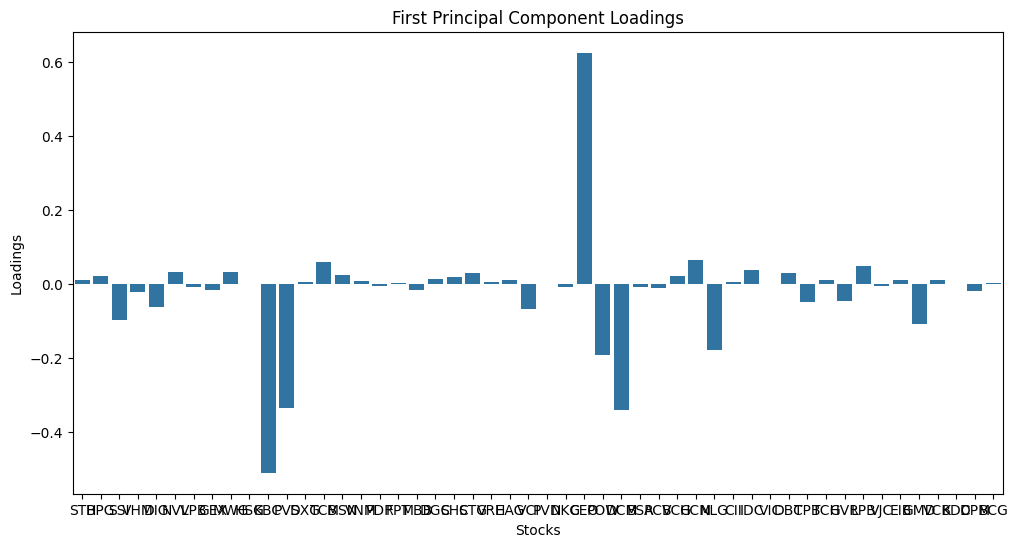

In [98]:
# visualixe the first principal component loadings
plt.figure(figsize=(12, 6))
sns.barplot(x=pca_result['stocks'], y=ex_pc1)
plt.xticks()
plt.title('First Principal Component Loadings')
plt.xlabel('Stocks')
plt.ylabel('Loadings')
plt.show()